# Extract individual trajectories from one recording

In [2]:
import sys
import numpy as np
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO
import event_representations
from player import VideoPlayer

In [3]:
buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/hdf5/" + "spin_0_rec1_converted.hdf5")

Event rates (in ms): [2 0 0 ... 0 0 1]


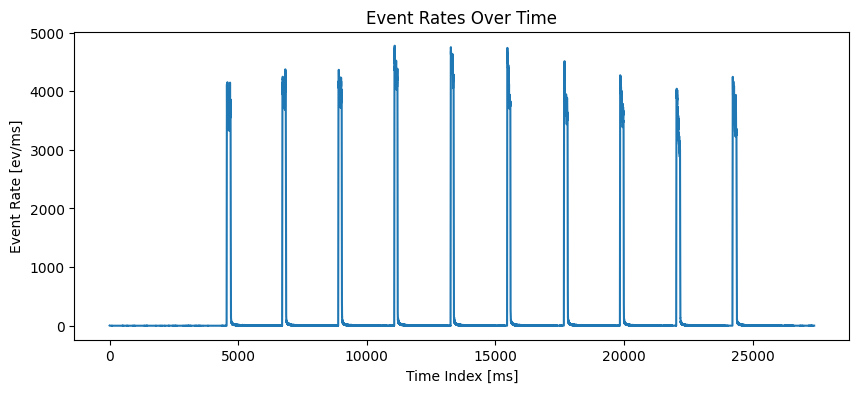

In [4]:
event_rates = buf.ms_to_idx[1:] - buf.ms_to_idx[:-1]
print("Event rates (in ms):", event_rates)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(event_rates)
plt.xlabel("Time Index [ms]")
plt.ylabel("Event Rate [ev/ms]")
plt.title("Event Rates Over Time")
plt.show()

## Extract timeframes with high event-rates

In [5]:
threshold = 1000  # Set a threshold for event rates [ev/ms]
high_rate_idxs = np.where(event_rates > threshold)[0]

# Group consecutive indices into individual spikes
spikes = []
if len(high_rate_idxs) > 0:
    current_spike = [high_rate_idxs[0]]
    for idx in high_rate_idxs[1:]:
        if idx == current_spike[-1] + 1:
            current_spike.append(idx)
        else:
            spikes.append(current_spike)
            current_spike = [idx]
    spikes.append(current_spike)

print(len(spikes))
print(spikes[0][0], spikes[0][-1])

10
4551 4712


## Get events for one spike

In [6]:
idx_spike1 = buf.ms_to_idx[spikes[0][0]], buf.ms_to_idx[spikes[0][-1]]
x_spike_1 = buf.get_x()[idx_spike1[0]:idx_spike1[1]]
y_spike_1 = buf.get_y()[idx_spike1[0]:idx_spike1[1]]
p_spike_1 = buf.get_p()[idx_spike1[0]:idx_spike1[1]]
ts_spike_1 = buf.get_ts()[idx_spike1[0]:idx_spike1[1]]

buf_spike1 = eventIO.EventBuffer(0)
buf_spike1.x = x_spike_1
buf_spike1.y = y_spike_1
buf_spike1.p = p_spike_1
buf_spike1.ts = ts_spike_1
buf_spike1.i = x_spike_1.shape[0]

## get images

In [7]:
print(buf_spike1.get_ts().min(), buf_spike1.get_ts().max(), buf_spike1.get_ts().max() - buf_spike1.get_ts().min())
start_ts = buf_spike1.get_ts().min()
end_ts = buf_spike1.get_ts().max()
print("Start time:", start_ts, "End time:", end_ts)
print(type(start_ts), type(end_ts))

4551000 4711998 160998
Start time: 4551000 End time: 4711998
<class 'numpy.uint64'> <class 'numpy.uint64'>


In [14]:
timeframe_us = 1000
start_ts = buf_spike1.get_ts().min()
end_ts = buf_spike1.get_ts().max()
end_ts += timeframe_us
end_ts = int(end_ts)
frames = []
for i in range(start_ts, end_ts, timeframe_us):
    idxs = np.where((buf_spike1.get_ts() >= i) & (buf_spike1.get_ts() < i + timeframe_us))[0]
    # print(idxs.shape)
    if len(idxs) == 0:
        frames.append(np.zeros((720, 1280), dtype=np.uint8))  # Append an empty frame if no events
        print(f"Empty frame at {i}")
    else:
        frame = event_representations.events_to_image(buf_spike1.get_x()[idxs], buf_spike1.get_y()[idxs], buf_spike1.get_ts()[idxs], buf_spike1.get_p()[idxs])
        frames.append(frame)

print(f"Generated {len(frames)} frames")

/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in divide
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)
/home/lkolmar/dev/Master_Thesis/notebooks/../src/utils/event_representations.py:31: RuntimeWarning: invalid value encountered in cast
  ps_normalized = ((ps - min_p) / (max_p - min_p) * 255).astype(np.uint8)


Empty frame at 4712000
Generated 162 frames


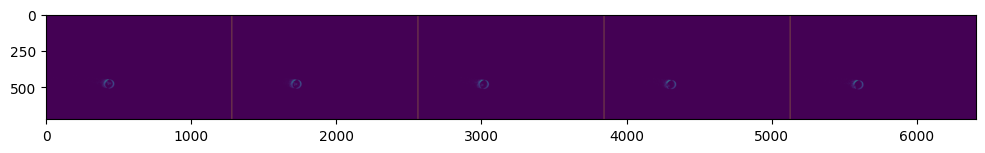

In [15]:
voxel = np.stack(frames[50:55], axis=0)
plt.imshow(event_representations.get_voxel_grid_as_image(voxel))
plt.gcf().set_size_inches(12, 8)
plt.show()

## Use player

In [17]:
# Map background to dark blue and event values to light blue
frames_img = []
for frame in frames:
    norm_frame = ((frame / 12) * 255).clip(0, 255).astype(np.uint8)
    img = np.zeros((norm_frame.shape[0], norm_frame.shape[1], 3), dtype=np.uint8)
    # Set background to dark blue
    img[:, :, 2] = 40  # B
    img[:, :, 1] = 0   # G
    img[:, :, 0] = 0   # R
    # Set event pixels to light blue
    mask = norm_frame > 0
    # print(norm_frame.shape, frame.shape, mask.shape, img.shape)
    img[mask, 2] = 220  # B
    img[mask, 1] = 180  # G
    img[mask, 0] = 100  # R
    frames_img.append(img)

In [ ]:
app = VideoPlayer(frames_img, fps=30)
app.mainloop()

In [19]:
def viz_events(events, height, width):
    img = np.full((height, width, 3), 128, dtype=np.uint8)
    img[events["y"], events["x"]] = 255 * events["p"][:, None]
    return img


class EROS:
    def __init__(self, h: int, w: int, k_eros: int = 50) -> None:
        self.k_eros = k_eros
        self.init_ts(h, w)
        self.d = 0.3 ** (1 / self.k_eros)  # Discount factor
        self.clean_kernel = np.array(
            [[-1, -1, -1], [-1, 1, -1], [-1, -1, -1]], dtype="int"
        )
        self.clean_kernel2 = np.array(
            [[-1, -1, -1, -1], [-1, 1, 1, -1], [-1, 1, 1, -1], [-1, -1, -1, -1]],
            dtype="int",
        )

    def init_ts(self, h: int, w: int):
        self.h = h
        self.w = w
        self.ts = np.zeros((self.h, self.w), dtype=np.float32)

    def update(self, events):
        """
        Updates the eros time surface with new events

        :param events struct array: Events from the event camera
        :param eros np.array: Image of the eros time surface
        :param k_eros int: Size of the updated area
        """
        for ev in events:
            bot = max(ev["y"] - self.k_eros, 0)
            top = min(ev["y"] + self.k_eros + 1, self.h)
            left = max(ev["x"] - self.k_eros, 0)
            right = min(ev["x"] + self.k_eros + 1, self.w)

            # Discount ts
            self.ts[bot:top, left:right] = self.d * self.ts[bot:top, left:right]

            self.ts[ev["y"], ev["x"]] = 255
        return self.ts

    def clean(self, n: int = 1):
        # kernel = np.ones((n, n), np.uint8)
        # f, axs = plt.subplots(3, sharex=True, sharey=True)
        # axs[0].imshow(self.ts)
        # self.ts = cv2.morphologyEx(self.ts, cv2.MORPH_OPEN, kernel)
        # self.ts = cv2.erode(self.ts, kernel, iterations=1)
        # start = time.time()
        # single_pixels = cv2.morphologyEx(
        #     self.ts.astype(np.uint8), cv2.MORPH_HITMISS, self.clean_kernel
        # )
        # single_pixels = cv2.morphologyEx(
        #     cv2.inRange(self.ts, 100, 255), cv2.MORPH_HITMISS, self.clean_kernel
        # )
        # single_pixels_inv = cv2.bitwise_not(single_pixels)
        # self.ts = cv2.bitwise_and(self.ts, self.ts, mask=single_pixels_inv)
        single_pixels = cv2.filter2D(
            src=cv2.inRange(self.ts, 1, 255), ddepth=-1, kernel=self.clean_kernel2
        )
        # mask = cv2.inRange(single_pixels, 100, 255)
        single_pixels_inv = cv2.bitwise_not(single_pixels)
        self.ts = cv2.bitwise_and(self.ts, self.ts, mask=single_pixels_inv)
        # print(time.time() - start)
        # axs[1].imshow(single_pixels)
        # axs[2].imshow(self.ts)
        # plt.show()



In [21]:
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import KalmanFilter

In [22]:
class KF:
    """
    Kalman filter for tracking ball with event camera
    The state is defined as:
        [x, y, vx, vy, r]
    where r is the estimated ball radius
    """

    def __init__(
        self, dt, Rpos=0.01**2, Rr=1**2, Qpos=1**2, Qvel=1e-3**2, Qr=0.5**2
    ) -> None:
        self.kf = KalmanFilter(dim_x=5, dim_z=3)
        # Dynamix matrix
        self.kf.F = np.array(
            [
                [1, 0, dt, 0, 0],
                [0, 1, 0, dt, 0],
                [0, 0, 1, 0, 0],
                [0, 0, 0, 1, 0],
                [0, 0, 0, 0, 1],
            ]
        )

        # Observation matrix
        self.kf.H = np.array([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 0, 0, 1]])

        # Measurement noise
        self.kf.R = np.array(
            [
                [Rpos, 0, 0],
                [0, Rpos, 0],
                [0, 0, Rr],
            ]
        )

        # Process noise
        self.kf.Q = np.array(
            [
                [Qpos, 0, 0, 0, 0],
                [0, Qpos, 0, 0, 0],
                [0, 0, Qvel, 0, 0],
                [0, 0, 0, Qvel, 0],
                [0, 0, 0, 0, Qr],
            ]
        )

    def init(self, x, P):
        self.kf.x = x
        self.kf.P = P

    def predict(self):
        self.kf.predict()
        return self.kf.x, self.kf.P

    def update(self, z):
        self.kf.update(z)
        return self.kf.x, self.kf.P


In [1]:
from metavision_sdk_cv import SpatioTemporalContrastAlgorithm

ModuleNotFoundError: No module named 'metavision_sdk_cv'

In [ ]:
class BallDetector:
    def __init__(
        self,
        h: int,
        w: int,
        k_eros: int = 10,
        r_min: int = 16,
        r_max: int = 22,
        erode_f: int = 1,
    ) -> None:
        self.eros = None
        self.k_eros = k_eros
        self.erode_f = erode_f
        self.erode_cnt = 0
        self.w = w
        self.h = h
        self.eros = EROS(h, w, k_eros)
        self.accums_thres = 20 # Threshold to check if a circle is detected or not
        self.init_stc_filter(self.h, self.w)
        self.hough_radii = np.arange(r_min, r_max, 1)
        self.ball_er = 100
        self.edg_min = 50

    def init_stc_filter(
        self, h: int, w: int, stc_filter_th: int = 5000, stc_cut_trail: bool = True   
    ):
        self.stc_filter = Spatio

## Find ROI